# Error Correction Model Parameter Estimation

The Error Correction for two $I(1)$ processes, $X_t$ and $Y_t$ the ECM is given by,

$
\begin{align}
\Delta Y_t = \gamma \Delta X_t + \lambda \left( Y_{t-1} - \beta X_{t-1} \right) + \nu_t
\end{align}
\tag{1}
$

where $\nu_t \sim \text{Normal}(0, \sigma^2)$.</br>

To perform parameter estimation let,

$
\begin{align}
\varepsilon_{t-1} = Y_{t-1} - \beta X_{t-1}
\end{align}
\tag{2}
$

OLS is used to used to estimate $\beta$ to obtain,

$
\begin{align}
\hat{\varepsilon}_{t-1} = Y_{t-1} - \hat{\beta} X_{t-1}
\end{align}
\tag{3}
$

where $\hat{\beta}$ is the OLS estimate of $\beta$. Next the ADF test is used to test $\hat{\varepsilon}_{t-1}$ for stationarity. Replacing the $Y_{t-1} - \beta X_{t-1}$ term in the ECM with $\hat{\varepsilon}_{t-1}$ gives

$
\begin{align}
\Delta Y_t = \gamma \Delta X_t - \lambda \hat{\varepsilon}_{t-1} + \nu_t
\end{align}
\tag{4}
$

Next $\gamma$ and $\lambda$ can be estimated using OLS. This is called the Granger two-step process.

In [32]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot
import statsmodels.api as sm

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import ecm, stats, adf, arima
from lib.plots import comparison, scatter
from lib.utils import create_ensemble

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [9]:
def ecm_comparison_plot(xt, yt, φ, β, γ, λ, σ=1.0):
    title = f"ECM Simulation: φ={φ}, β={β}, γ={γ}, λ={λ}, σ={σ}"
    εt = yt - β * xt
    labels = [r"$x_t$", r"$y_t$", r"$\hat{\varepsilon}=y_t - \hat{\beta}x_t$"]
    comparison([xt, yt, εt], title=title, ylabel=r"$S_t$", xlabel=r"$t$", labels=labels, lw=1)

## Simulation Parameters

In [13]:
φ = 0.5
β = 0.5
λ = -0.25
γ = 0.75
npts = 1000

### $\beta$ Estimation

In [27]:
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)

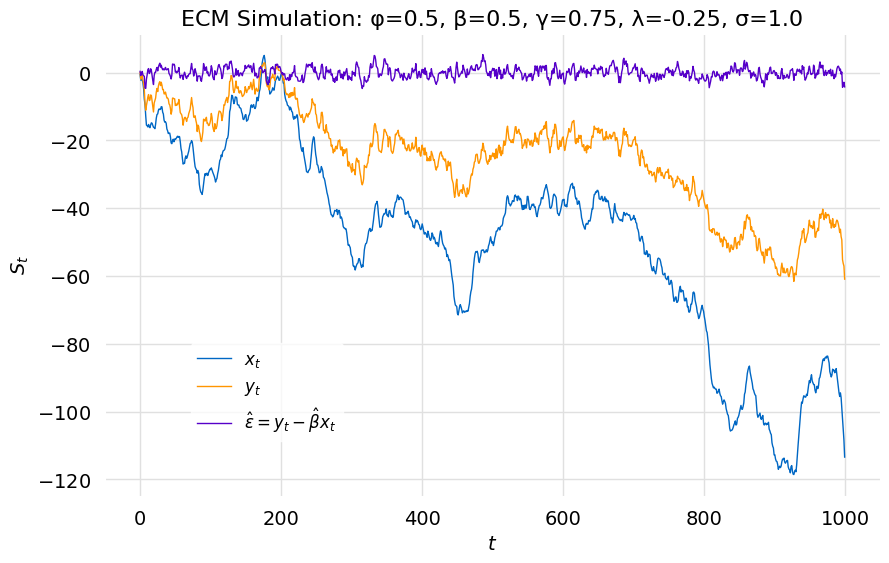

In [28]:
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

### Residual Stationarity

In [29]:
εt = yt - β * xt
result, result_model = adf.compute_adf_test(εt)
result.summary()

╒════════════════╤══════════════╕
│ Test Statistic │ -12.2031     │
├────────────────┼──────────────┤
│ pvalue         │   2.9447e-22 │
├────────────────┼──────────────┤
│ Lags           │   0          │
├────────────────┼──────────────┤
│ Number Obs     │ 999          │
╘════════════════╧══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56798 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


In [30]:
print(result_model.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "label": "$t$",
                "value": -12.203129792431112,
                "hyp_test_id": "1b9ee590-fa51-41b1-b85a-c737e0b1d4cc"
            },
            "pval": {
                "label": "$p-value$",
                "value": 2.9446969861319196e-22,
                "hyp_test_id": "1b9ee590-fa51-41b1-b85a-c737e0b1d4cc"
            },
            "params": [],
            "sig": {
                "label": "1%",
                "value": 0.01,
                "hyp_test_id": "1b9ee590-fa51-41b1-b85a-c737e0b1d4cc"
            },
            "lower": {
                "label": "$t_L$",
                "value": -2.5679816723029334,
                "hyp_test_id": "1b9ee590-fa51-41b1-b85a-c737e0b1d4cc"
            },
            "upper": null,
            "hyp_test_id": "1b9ee590-fa51-41b1-b85a-c737e0

In [18]:
result, result_model = ecm.compute_beta_estimate(yt, xt)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.937
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                 1.489e+04
Date:                Sun, 24 Sep 2023   Prob (F-statistic):               0.00
Time:                        16:46:52   Log-Likelihood:                -2575.7
No. Observations:                1000   AIC:                             5155.
Df Residuals:                     998   BIC:                             5165.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1199      0.106      1.133      0.257      -0.088       0.328
x1             1.8355      0.015    122.032      0.000       1.806       1.865
==============================================================================
Omnibus:                        4.261   Durbin-Watson:                   0.424
Prob(Omnibus):                  0.119   Jarque-Bera (JB):                5.030
Skew:                           0.021   Prob(JB):                       0.0808
Kurtosis:                       3.345   Cond. No.                         7.41
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [33]:
x = sm.add_constant(xt)
result = sm.OLS(yt, x, missing='drop').fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                 9.130e+04
Date:                Sun, 24 Sep 2023   Prob (F-statistic):               0.00
Time:                        18:58:10   Log-Likelihood:                -1864.6
No. Observations:                1000   AIC:                             3733.
Df Residuals:                     998   BIC:                             3743.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2456      0.097      2.533      0.011       0.055       0.436
x1             0.5060      0.002    302.158      0.000       0.503       0.509
==============================================================================
Omnibus:                        0.712   Durbin-Watson:                   0.536
Prob(Omnibus):                  0.700   Jarque-Bera (JB):                0.658
Skew:                           0.062   Prob(JB):                        0.720
Kurtosis:                       3.023   Cond. No.                         114.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

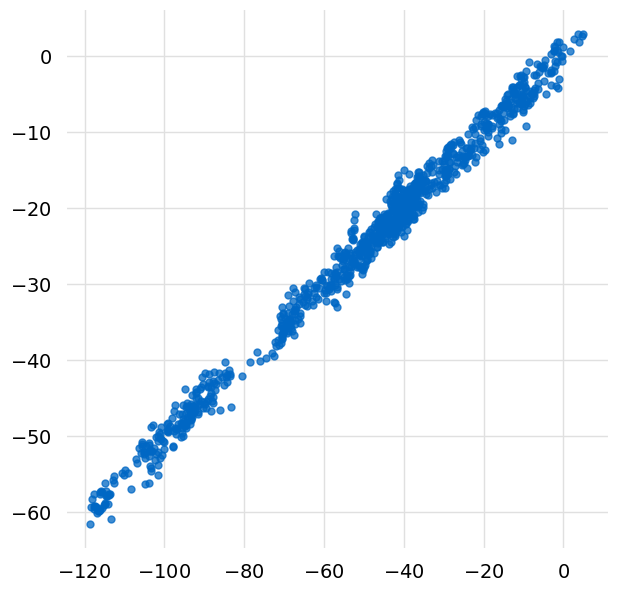

In [31]:
scatter(yt, xt, figsize=(7, 7))